# Task 1: Problem Identification

Selected Problem Type: Image Classification (Multi-Class Classification)

The given dataset represents an image classification problem because it contains product surface images categorized into four classes: normal, scratch, dent, and stain.

Each image belongs to one class, and the objective is to predict the correct category for new images.

This is not object detection because no bounding boxes are required. It is not segmentation because no pixel-level annotations are provided.

In [11]:
!unzip part_2_cnn_computer_vision-20260515T125945Z-3-001.zip

Archive:  part_2_cnn_computer_vision-20260515T125945Z-3-001.zip
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_109.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_037.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_012.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_069.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_005.png  
  inflating: part_2_cnn_computer_vision/labels.csv  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_108.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_032.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_004.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_008.png  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_083.png  
  inflating: part_2_cnn_computer_vision/.DS_Store  
  inflating: part_2_cnn_computer_vision/images/scratch/scratch_098.png  
  inflating: part_2_cnn_comp

In [12]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
dataset_path = "/content/part_2_cnn_computer_vision/images"

classes = ['normal', 'scratch', 'dent', 'stain']

image_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)
    image_counts[cls] = len(images)

print("Number of classes:", len(classes))
print("\nImages per class:")

for cls, count in image_counts.items():
    print(f"{cls}: {count}")

Number of classes: 4

Images per class:
normal: 120
scratch: 120
dent: 120
stain: 120


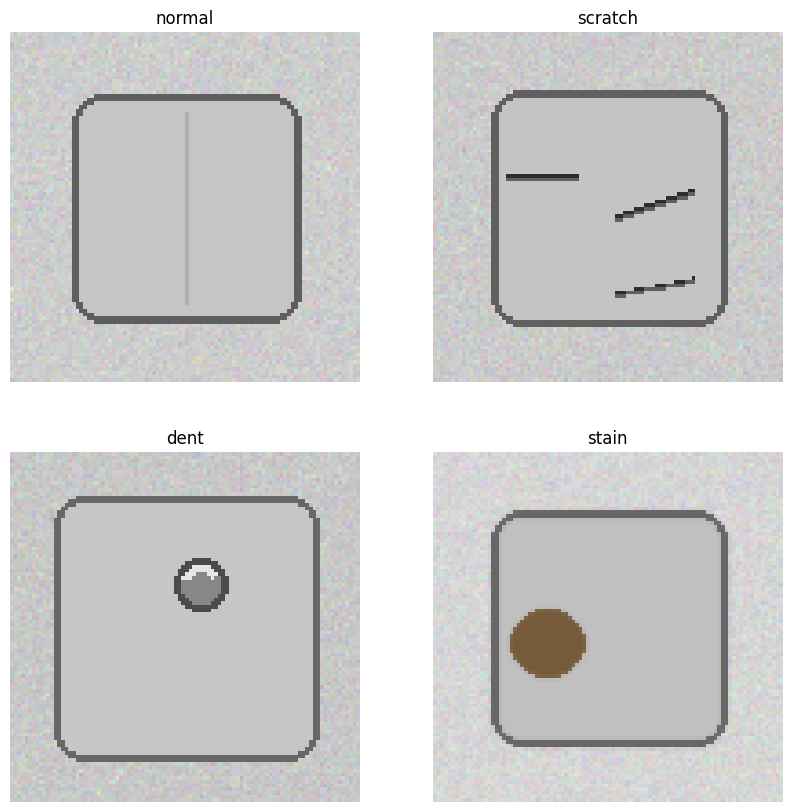

In [14]:
plt.figure(figsize=(10,10))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [15]:
for cls in classes:
    img_name = os.listdir(os.path.join(dataset_path, cls))[0]
    img_path = os.path.join(dataset_path, cls, img_name)

    img = cv2.imread(img_path)
    print(f"{cls}: {img.shape}")

normal: (96, 96, 3)
scratch: (96, 96, 3)
dent: (96, 96, 3)
stain: (96, 96, 3)


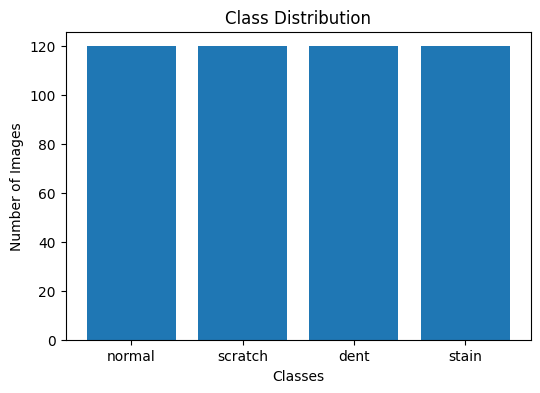

In [16]:
plt.figure(figsize=(6,4))
plt.bar(image_counts.keys(), image_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.show()

In [17]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [18]:
dataset_path = "/content/part_2_cnn_computer_vision/images"

classes = ['normal', 'scratch', 'dent', 'stain']

X = []
y = []

img_size = 96   # fixed size

for label, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (img_size, img_size))
        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)

Images shape: (480, 96, 96, 3)
Labels shape: (480,)


In [19]:
X = X / 255.0

print("Pixel range:", X.min(), "to", X.max())

Pixel range: 0.17647058823529413 to 1.0


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (384, 96, 96, 3)
Testing data: (96, 96, 96, 3)


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# Task 3: Image Preprocessing

The dataset images were preprocessed before model training.

Preprocessing steps included:

- Resizing all images to a fixed size of **96 × 96 pixels**
- Normalizing pixel values from **0–255 to 0–1**
- Splitting the dataset into **80% training data and 20% testing data**
- Applying **data augmentation** using rotation, zoom, and horizontal flipping to improve model generalization

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(96,96,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: CNN Model Creation

A Convolutional Neural Network (CNN) model was created using TensorFlow/Keras for multi-class image classification.

Model architecture includes:

- **Convolution layers** to extract image features
- **ReLU activation function** for non-linearity
- **Max pooling layers** to reduce feature map dimensions
- **Flatten layer** to convert feature maps into 1D vectors
- **Dense layer** for classification learning
- **Dropout layer** to reduce overfitting
- **Softmax output layer** for 4-class prediction

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [3]:
import os

os.makedirs("results", exist_ok=True)
os.makedirs("sample_predictions", exist_ok=True)

In [24]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 760ms/step - accuracy: 0.2370 - loss: 1.4086 - val_accuracy: 0.2500 - val_loss: 1.3866
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 595ms/step - accuracy: 0.2812 - loss: 1.3862 - val_accuracy: 0.4479 - val_loss: 1.3791
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 728ms/step - accuracy: 0.3151 - loss: 1.3661 - val_accuracy: 0.2500 - val_loss: 1.3114
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 603ms/step - accuracy: 0.4427 - loss: 1.2326 - val_accuracy: 0.7083 - val_loss: 1.1211
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 711ms/step - accuracy: 0.5911 - loss: 1.0894 - val_accuracy: 0.7396 - val_loss: 0.7985
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 719ms/step - accuracy: 0.7422 - loss: 0.6699 - val_accuracy: 0.8542 - val_loss: 0.4056
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 584ms/step - accuracy: 0.8281 - loss: 0.4717 - val_accuracy: 0.8958 - val_loss: 0.3058
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 727ms/step - accuracy: 0.8490 - loss: 0.4047 - val_accuracy: 0

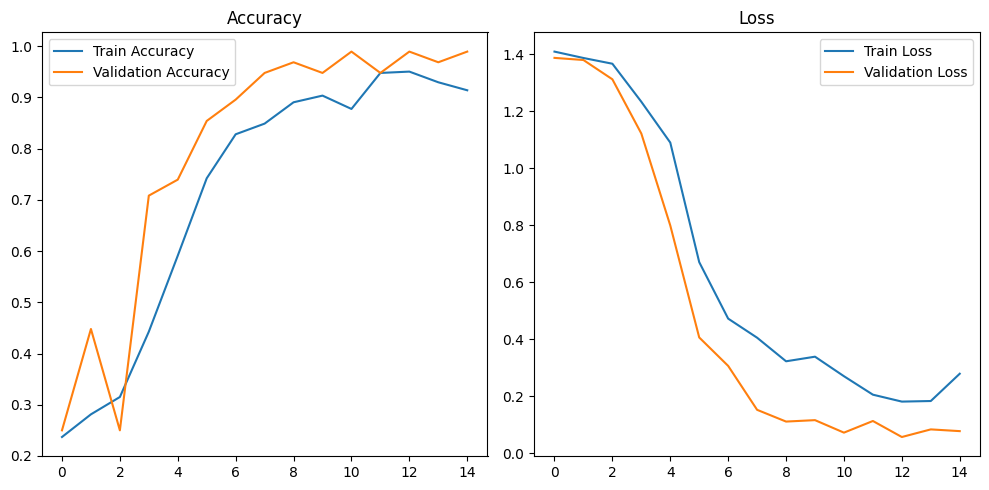

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.savefig("results/accuracy_loss_curves.png")
plt.show()

In [26]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.9896 - loss: 0.0769
Test Accuracy: 0.9895833134651184
Test Loss: 0.07692194730043411


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 243ms/step


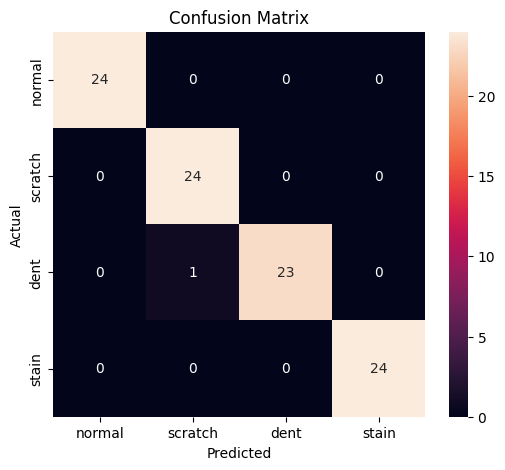

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("results/confusion_matrix.png")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


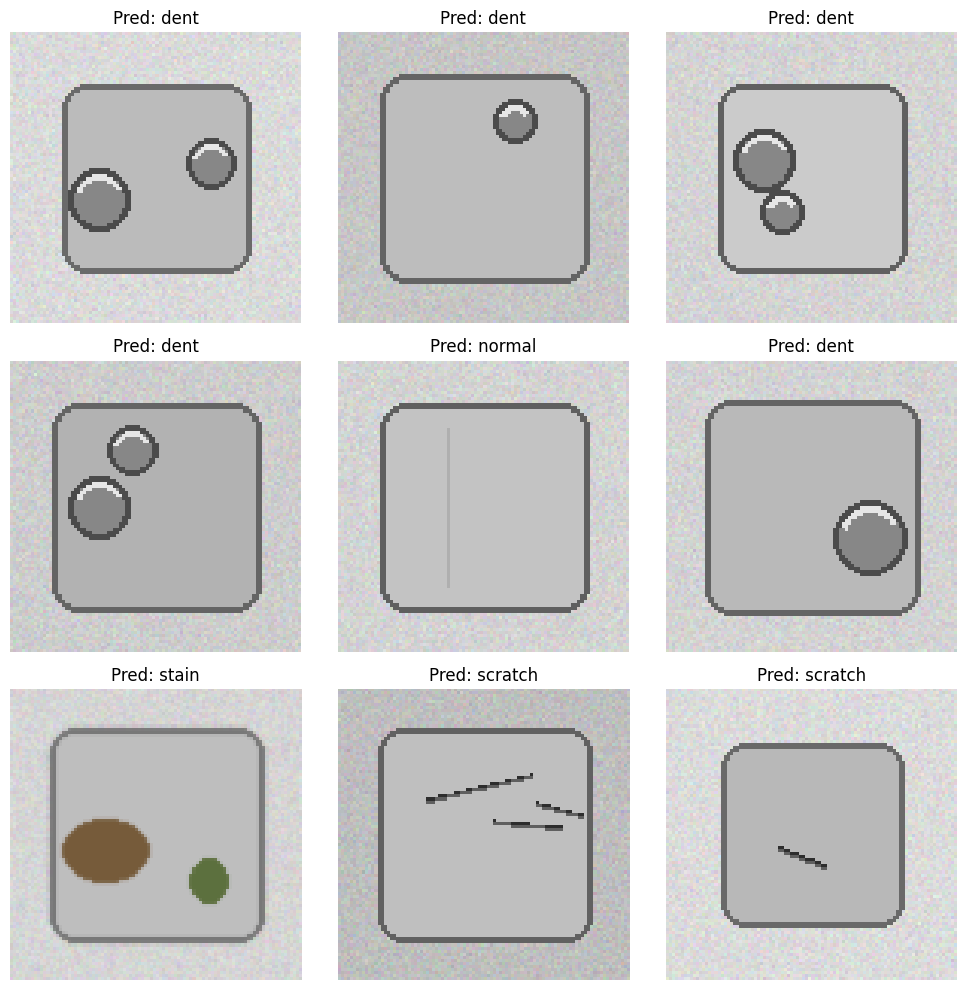

In [28]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)

    img = X_test[i]
    pred = model.predict(np.expand_dims(img, axis=0))
    pred_class = classes[np.argmax(pred)]

    plt.imshow(img)
    plt.title(f"Pred: {pred_class}")
    plt.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions/prediction_outputs.png")
plt.show()

# Task 5: Model Training and Evaluation

The CNN model was trained for 15 epochs using augmented training data.

Evaluation included:

- Training and validation accuracy/loss
- Test dataset performance
- Confusion matrix analysis
- Sample predictions on unseen test images

Generated output files:

- results/accuracy_loss_curves.png
- results/confusion_matrix.png
- sample_predictions/prediction_outputs.png